# ✈️ NASA C-MAPSS FD001 — EDA + 전처리 + Feature Engineering + Validation Split 파이프라인

** **ML·DL 통합 분기 / DL Long Format CSV 저장 / random_state=42 엔진 분할**

공통: 상수 센서 제거 → RUL cap=125 → Gaussian → Validation 분할 → 정규화  
ML 분기: lag·diff·rolling·std·EMA  |  DL 분기: 슬라이딩 윈도우

이번 버전은 **가우시안 스무딩 → 엔진 단위 랜덤 validation 분리(random_state=42) → sub-train 기준 정규화 → ML/DL 분기 처리** 흐름으로 구성했습니다.


이번 최종본은 **rolling std / EMA까지 포함한 시계열 파생변수**, **엔진 단위 랜덤 validation 분리(random_state=42)**, **sub-train 기준 정규화**를 반영한 버전이다.

# 전처리 실험 1 _ CAP = 120으로 변경하여 실험! RUL 클리핑 외의 다른 값들은 전부 동일함

## 0. 환경 설정

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 다크 테마 ──────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})

# ── 전역 상수 ──────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1,22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
RUL_CAP      = 125
GAUSS_SIGMA  = 2
CONST_THR    = 0.01

TEMPORAL_LAGS  = [1, 3, 5]
TEMPORAL_DIFFS = [1]
TEMPORAL_ROLLS = [3, 5]

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS = [5]


✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01


## 1. 데이터 로딩 & 컬럼명 표준화

In [2]:
DATA_DIR = '../YJ'

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD001.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

# 컬럼명 표준화 (로딩 즉시)
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD001 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD001 로딩 완료
   Train : (20631, 26)  |  엔진 100대
   Test  : (13096, 26)   |  엔진 100대
   RUL   : (100, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


---
## 4. 결정 1 — 상수 센서 제거 (21개 → 14개)

**근거:** 비행 내내 값이 거의 변하지 않는 센서는 열화 정보를 담지 못함. 기준: `std < 0.01`  
> ⚠️ 기준은 **train**에서만 계산 → **동일 피처 목록**을 test에 적용 (누수 방지)

제거 (7개): ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
유지 (14개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


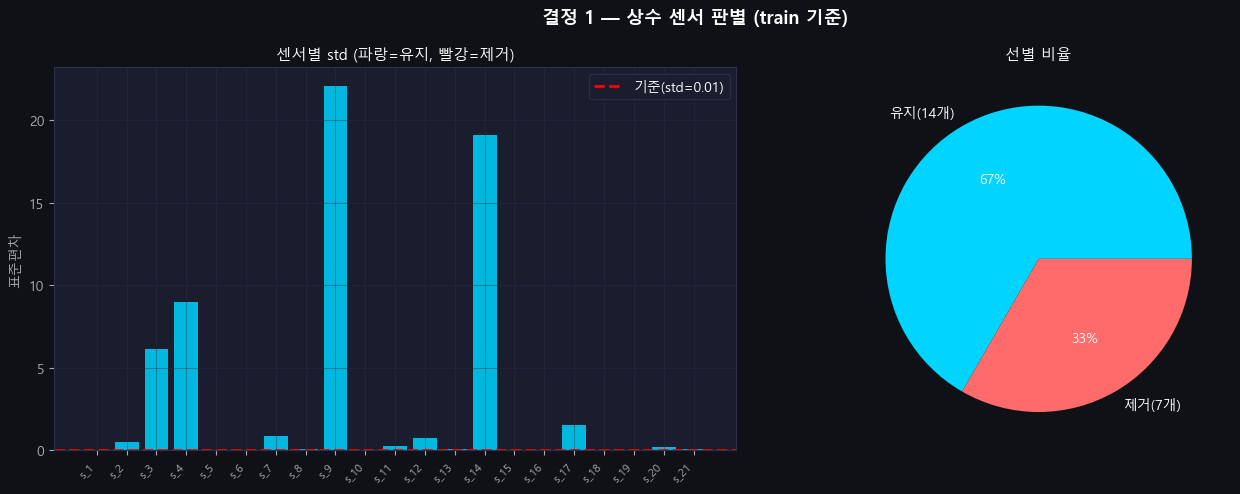


✅ 결정 1 완료: 26 → 19 컬럼


In [3]:
train_std      = train_raw[SENSOR_COLS].std()
USEFUL_SENSORS = train_std[train_std >= CONST_THR].index.tolist()
CONST_SENSORS  = train_std[train_std <  CONST_THR].index.tolist()

print(f'제거 ({len(CONST_SENSORS)}개): {CONST_SENSORS}')
print(f'유지 ({len(USEFUL_SENSORS)}개): {USEFUL_SENSORS}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 1 — 상수 센서 판별 (train 기준)', fontsize=13, fontweight='bold')

ax = axes[0]
colors = [C[0] if s in USEFUL_SENSORS else C[1] for s in SENSOR_COLS]
ax.bar(range(len(SENSOR_COLS)), train_std.values, color=colors, alpha=0.85)
ax.axhline(CONST_THR, color='red', ls='--', lw=2, label=f'기준(std={CONST_THR})')
ax.set_xticks(range(len(SENSOR_COLS)))
ax.set_xticklabels(SENSOR_COLS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('표준편차')
ax.set_title('센서별 std (파랑=유지, 빨강=제거)')
ax.legend()

ax = axes[1]
ax.pie([len(USEFUL_SENSORS), len(CONST_SENSORS)],
       labels=[f'유지({len(USEFUL_SENSORS)}개)', f'제거({len(CONST_SENSORS)}개)'],
       colors=[C[0], C[1]], autopct='%1.0f%%',
       textprops={'color':WHITE})
ax.set_title('선별 비율')
plt.tight_layout(); plt.show()

# 적용 (train 기준 피처 → test에도 동일 적용)
KEEP = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()   # train 기준 피처 목록 그대로

print(f'\n✅ 결정 1 완료: {train_raw.shape[1]} → {train_s1.shape[1]} 컬럼')

## 5. 결정 2 — Piecewise RUL 생성 (Cap = 125)

**근거:** 100% 엔진이 수명 125 초과. 마지막 125 사이클(위험 구간)에만 모델이 집중하도록 함.  
> **train 전용** — test의 RUL은 `RUL_FD001.txt`에서 직접 가져옴

In [ ]:
def add_piecewise_rul(df, cap=RUL_CAP):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)

train_s2 = add_piecewise_rul(train_s1)
test_s2  = test_s1.copy()

# Cap 민감도 분석
caps = [100, 115, 125, 135, 150]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('결정 2 — Cap 민감도 분석 (강조=선택된 Cap=125)', fontsize=13, fontweight='bold')

for ax, cap in zip(axes, caps):
    tmp = train_s2['RUL_raw'].clip(upper=cap)
    pct = (train_s2['RUL_raw']>=cap).mean()*100
    ax.hist(tmp, bins=30, color=C[0] if cap==125 else GRAY, alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'Cap={cap}\n({pct:.0f}% 집중)',
                 color='#ffd43b' if cap==125 else WHITE, fontsize=9)
    ax.set_xlabel('Piecewise RUL')
    if cap==125: ax.patch.set_facecolor('#1a1040')
plt.tight_layout(); plt.show()

# 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 2 — Raw vs Piecewise RUL 비교', fontsize=13, fontweight='bold')

ax = axes[0]
for u in train_s2['unit_nr'].unique()[:20]:
    sub = train_s2[train_s2['unit_nr']==u].sort_values('time_cycles')
    ax.plot(sub['time_cycles'], sub['RUL_raw'], color=GRAY,  alpha=0.25, lw=0.8)
    ax.plot(sub['time_cycles'], sub['RUL'],     color=C[0], alpha=0.7,  lw=1.2)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_xlabel('time_cycles'); ax.set_ylabel('RUL'); ax.set_title('RUL 궤적 비교'); ax.legend()

ax = axes[1]
ax.hist(train_s2['RUL_raw'], bins=40, alpha=0.4, color=GRAY,  density=True, label='Raw RUL')
ax.hist(train_s2['RUL'],     bins=40, alpha=0.8, color=C[0], density=True, label='Piecewise')
ax.set_xlabel('RUL'); ax.set_ylabel('밀도'); ax.set_title('분포 비교'); ax.legend()
plt.tight_layout(); plt.show()

raw_std, piece_std = train_s2['RUL_raw'].std(), train_s2['RUL'].std()
print(f'✅ 결정 2 완료  |  RUL std: {raw_std:.1f} → {piece_std:.1f} ({(1-piece_std/raw_std)*100:.0f}% 감소)')

SyntaxError: invalid character '—' (U+2014) (2564690231.py, line 4)